In [6]:
import pandas as pd
from sympy.physics.units import year

from configs.feature_config import RAW_FEATURES, TARGET
from src.data.data_cleaner import DataCleaner
from src.features.feature_engineering import build_derived_features
from src.pipelines.data_pipeline import compute_target
from src.utils.utils import load_raw_dataset

df = build_derived_features(DataCleaner().fit_transform(load_raw_dataset()))
target = TARGET['listing_gain_perc']
df[target] = compute_target(df, 5)
df


,Assets (Rs.cr.),EPS (Rs.) Pre-IPO,Ebitda (Rs.cr.),Issue Amount (Rs.cr.),Issue Price (Rs.),NII (x),Net Worth (Rs.cr.),Open Price on Listing (Rs.),P/E (x) Pre-IPO,PAT Margin %,...,ipoStartDate,price_band_high,price_band_low,year,~IPO_Listing_Date,qib_ratio,retail_ratio,nii_ratio,is_gmp_missing,listing_gain_perc
0,61.59,1.85,8.63,250.80,114,4.73,30.56,120.00,61.62,23.61,...,2025-12-22,114.0,108.0,2025,2025-12-30 00:00:00+00:00,0.345029,5.353801,1.383041,1,1
1,793.28,11.97,40.28,626.35,384,0.45,321.47,370.00,32.09,3.51,...,2025-12-16,384.0,365.0,2025,2025-12-23 00:00:00+00:00,1.193878,0.948980,0.459184,1,0
2,4827.34,53.63,2210.10,10602.65,2165,21.00,3921.56,2600.00,40.37,NaN,...,2025-12-12,2165.0,2061.0,2025,2025-12-19 00:00:00+00:00,1.787513,0.085846,0.744945,1,1
3,2320.93,5.55,217.14,920.00,162,15.51,1153.05,158.80,29.21,15.30,...,2025-12-10,162.0,154.0,2025,2025-12-17 00:00:00+00:00,0.892800,0.518400,2.481600,1,0
4,1193.68,7.24,110.31,871.05,460,24.73,716.06,490.00,63.52,8.88,...,2025-12-10,460.0,438.0,2025,2025-12-17 00:00:00+00:00,1.115613,0.226285,2.443676,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,25448.81,NaN,NaN,64.50,150,17.62,6243.47,175.55,NaN,NaN,...,2006-09-01,150.0,130.0,2006,2006-09-25 00:00:00+00:00,0.775781,1.160833,1.666982,1,1
716,19806.53,NaN,NaN,40.68,36,0.31,NaN,49.00,NaN,NaN,...,NaT,256.5,243.0,2006,2006-09-25 00:00:00+00:00,6.500000,2.474820,0.223022,1,1
717,14.05,NaN,NaN,168.49,345,22.58,NaN,370.00,NaN,NaN,...,2006-08-24,345.0,295.0,2006,2006-09-20 00:00:00+00:00,1.453080,0.373057,1.299942,1,1
718,121.77,NaN,NaN,40.00,21,27.97,42.36,30.00,NaN,NaN,...,2006-01-06,21.0,18.0,2006,2006-02-02 00:00:00+00:00,0.389521,1.889273,1.382600,1,1


Analyzing target variable

In [2]:
col1, col2, target = df[TARGET['listing_price']], df[TARGET['issue_price']], TARGET['listing_gain_perc']
df[target] = ((col1-col2)/col2)*100
df[target]

0       5.263158
1      -3.645833
2      20.092379
3      -1.975309
4       6.521739
         ...    
715    17.033333
716    36.111111
717     7.246377
718    42.857143
719    37.500000
Name: listing_gain_perc, Length: 720, dtype: float64

In [3]:
(df[target] >= 5).value_counts(normalize=True)

listing_gain_perc
True     0.576389
False    0.423611
Name: proportion, dtype: float64

In [7]:
year = RAW_FEATURES['year']
pd.crosstab(df[year], df[target], normalize='index') * 100

listing_gain_perc,0,1
year,,
2006,21.739130,78.260870
2007,29.333333,70.666667
2008,29.166667,70.833333
2009,68.750000,31.250000
2010,46.000000,54.000000
2011,70.833333,29.166667
2012,66.666667,33.333333
2013,66.666667,33.333333
2014,20.000000,80.000000


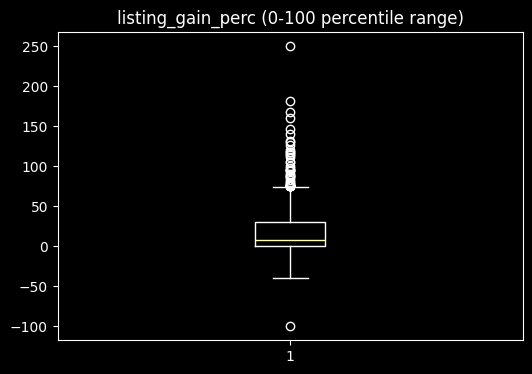

Lower whisker: -39.6296
25% (Q1): 0
50% (Median): 8.16667
Mean: 18.7153
75% (Q3): 29.9017
Upper whisker: 74.4902


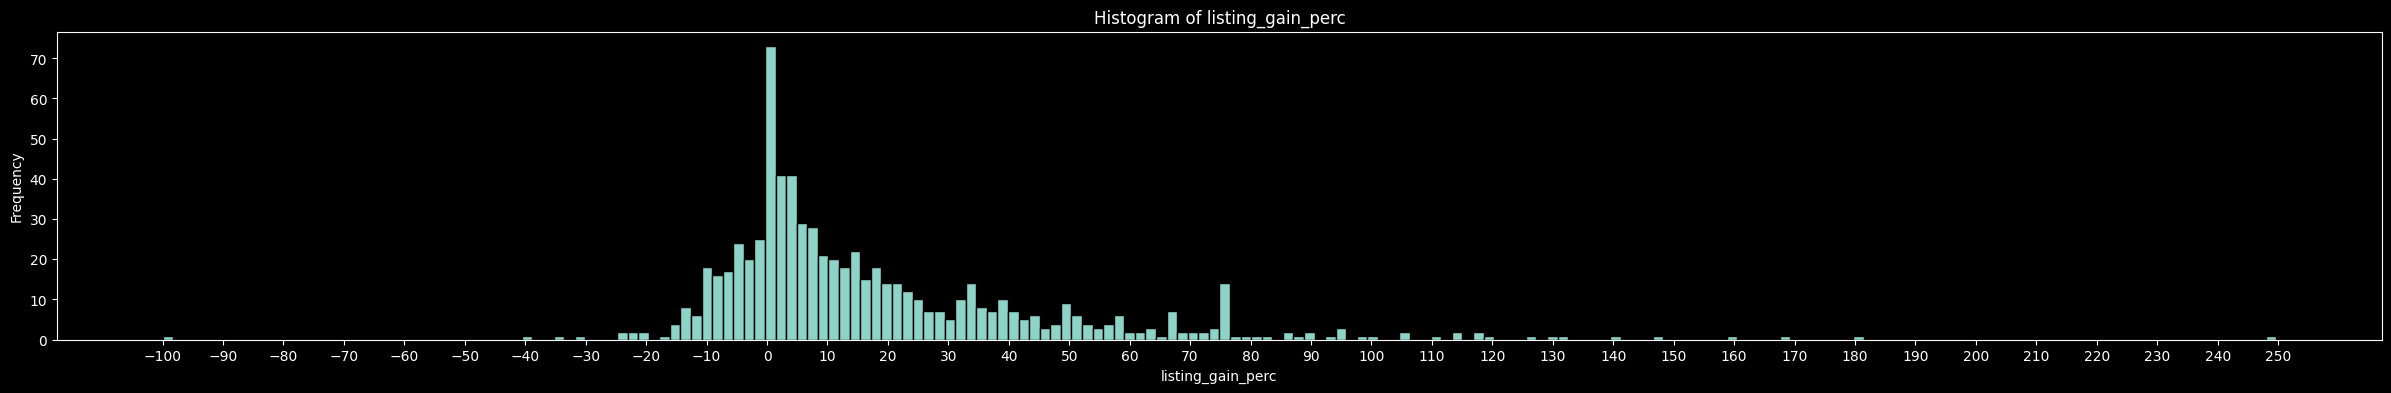

In [4]:
from src.utils.eda_utils import *

plot_boxplot_range(df, target, upper=100)
plot_histogram(df, target, 200, 10)

Analyzing input features

Qib, nii, retail, total

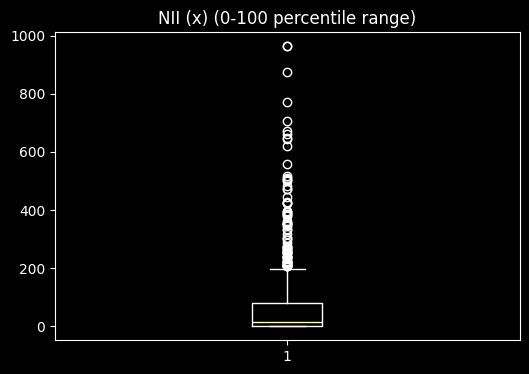

Lower whisker: 0.02
25% (Q1): 1.7
50% (Median): 15.03
Mean: 71.7355
75% (Q3): 80.395
Upper whisker: 198.34


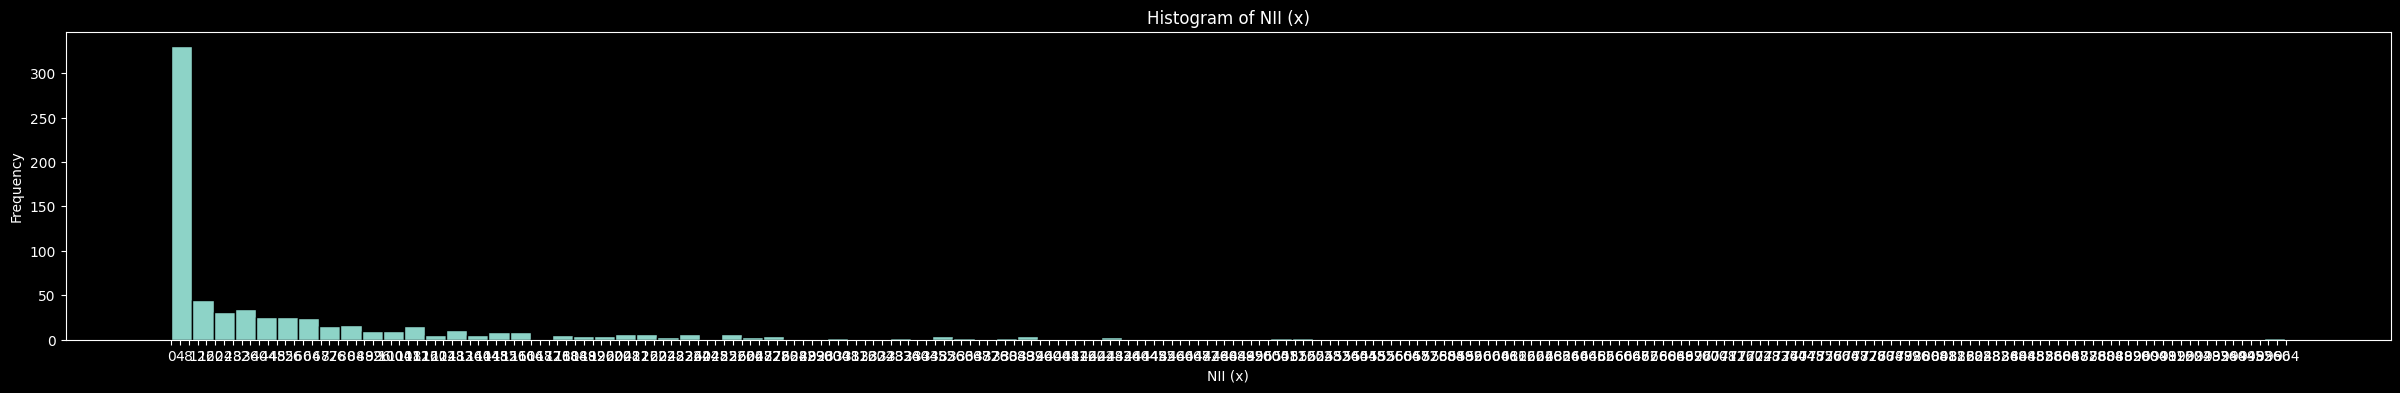

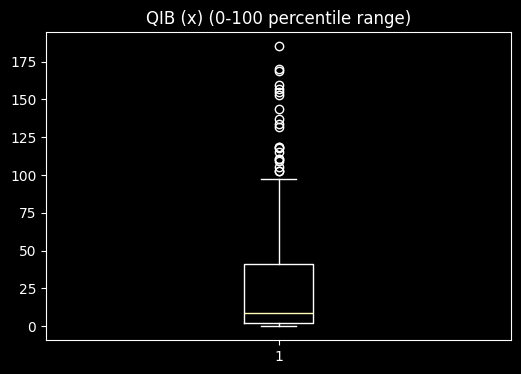

Lower whisker: 0
25% (Q1): 2.165
50% (Median): 9.035
Mean: 25.4856
75% (Q3): 41.2125
Upper whisker: 97.41


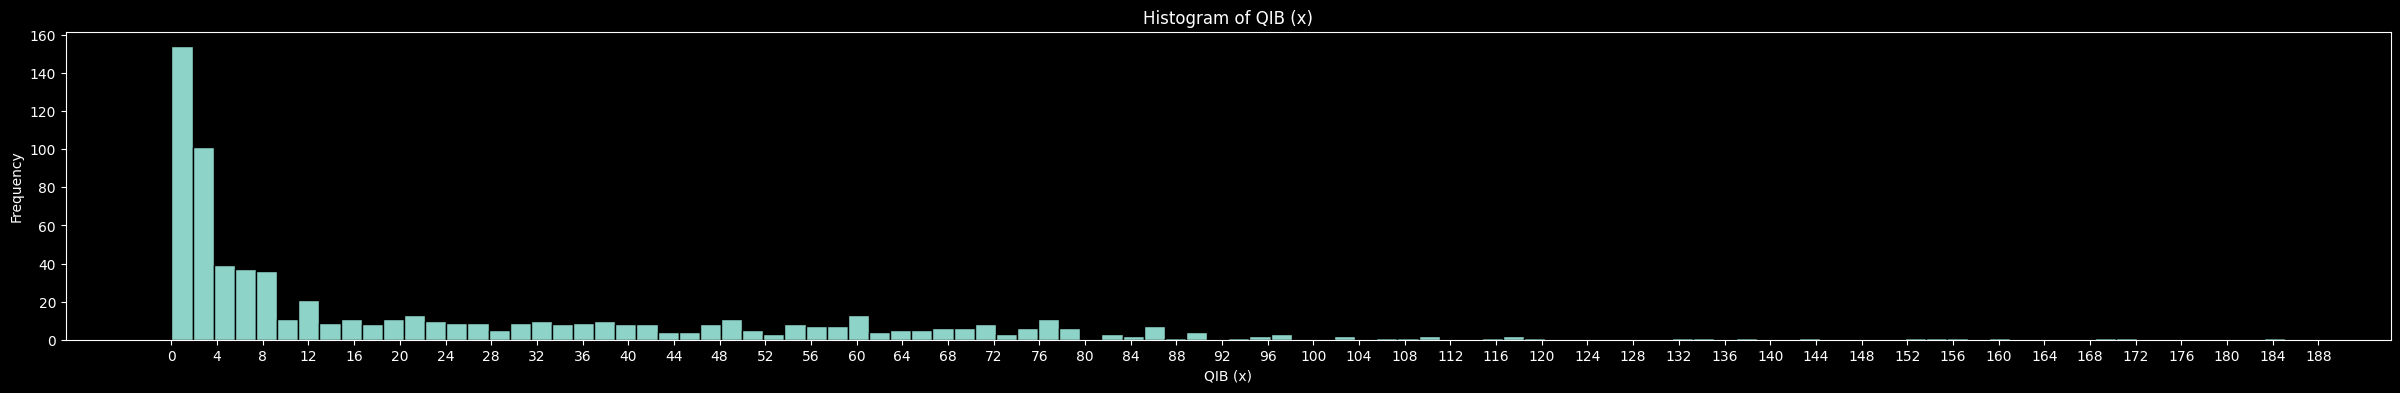

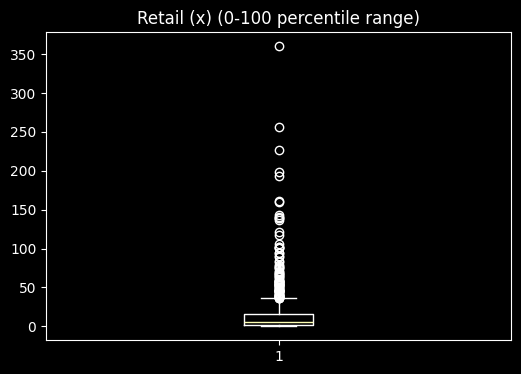

Lower whisker: 0.02
25% (Q1): 1.7075
50% (Median): 5.56
Mean: 15.9722
75% (Q3): 15.385
Upper whisker: 35.79


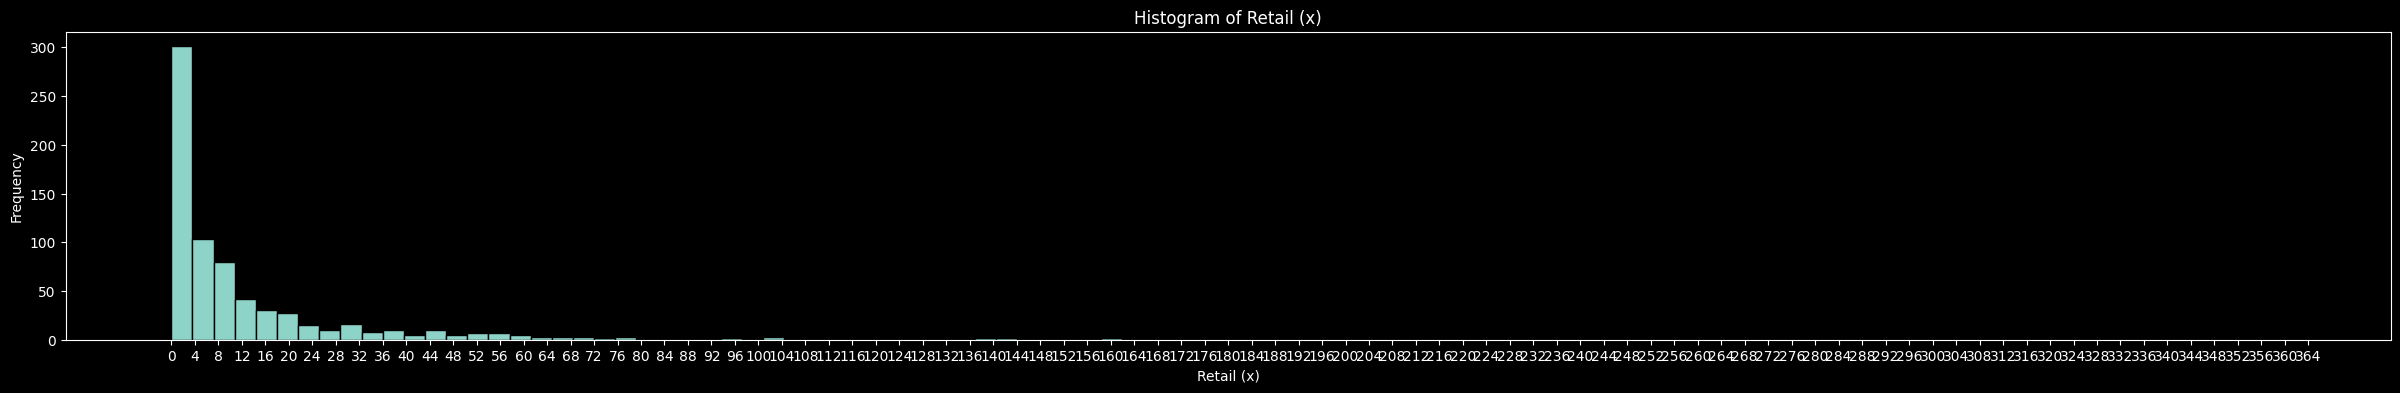

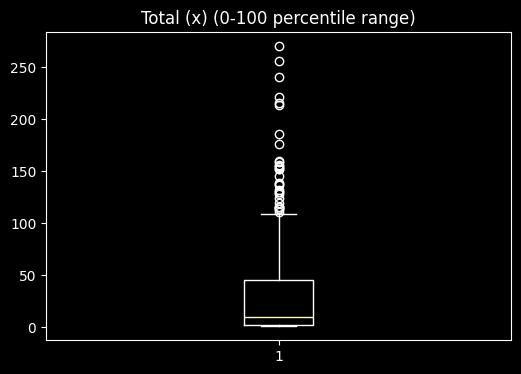

Lower whisker: 0.8
25% (Q1): 2.0325
50% (Median): 10.155
Mean: 28.7038
75% (Q3): 45.3125
Upper whisker: 109.21


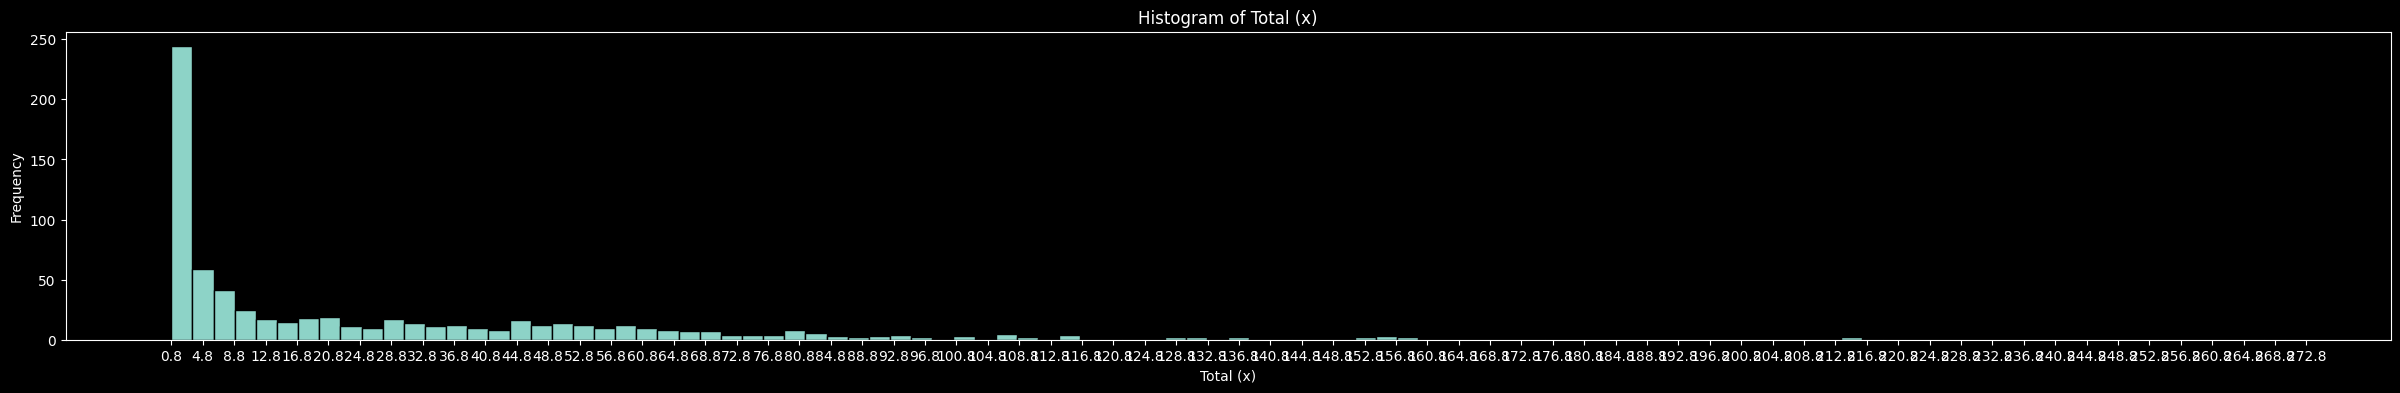

In [5]:
features = [
    RAW_FEATURES["nii"],
    RAW_FEATURES["qib"],
    RAW_FEATURES["retail"],
    RAW_FEATURES["total"]
]
for feature in features:
    plot_boxplot_range(df, feature)
    plot_histogram(df, feature, bins=100, step_size=4)

Year

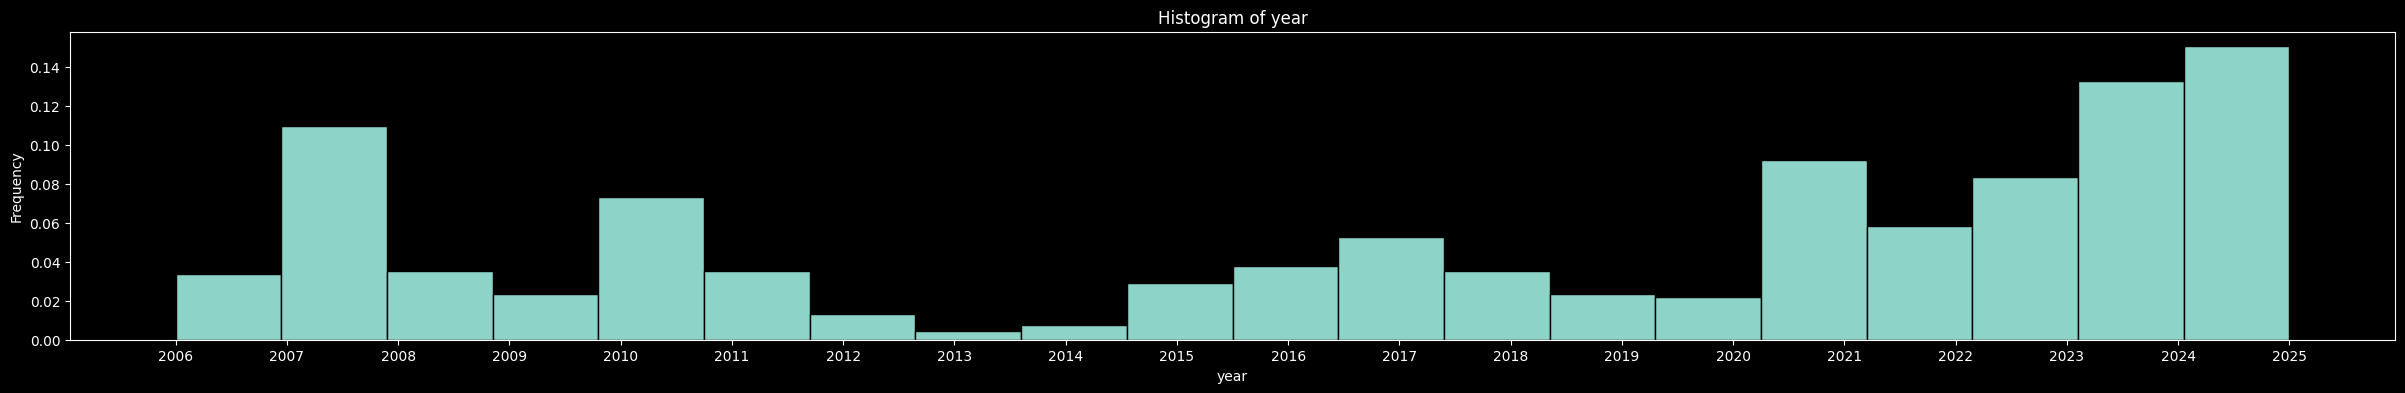

In [6]:
year = RAW_FEATURES['year']
plot_histogram(df, year, 20, 1, True)

NII to total ratio, QiB to Total ratio, Retail to total ratio

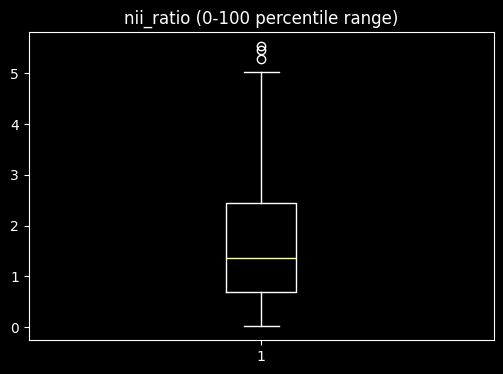

Lower whisker: 0.0173913
25% (Q1): 0.682854
50% (Median): 1.36327
Mean: 1.70644
75% (Q3): 2.44747
Upper whisker: 5.02566


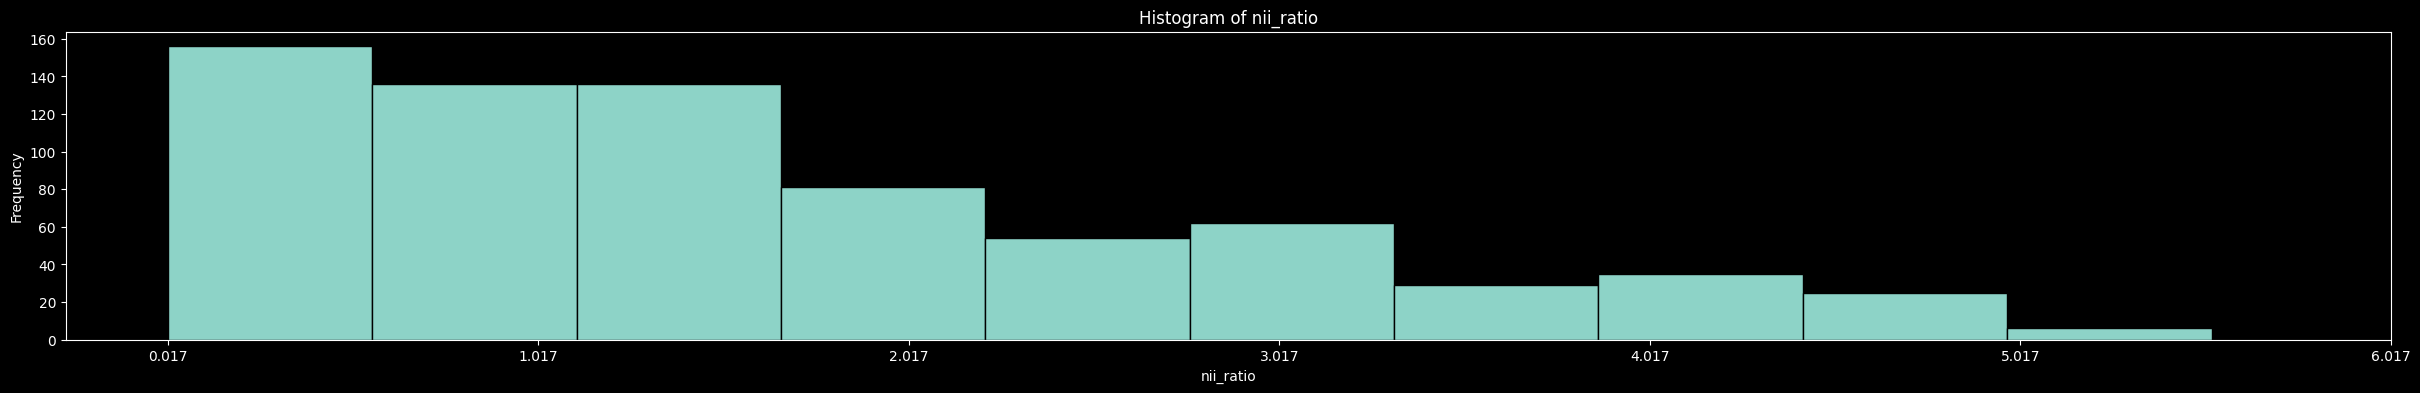

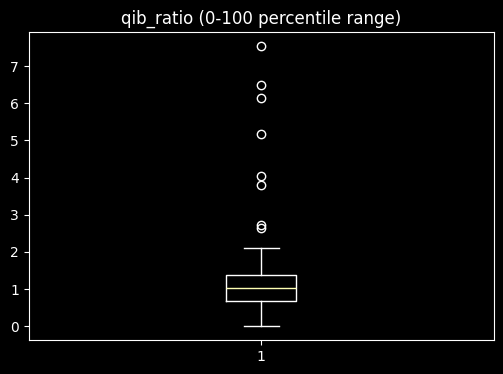

Lower whisker: 0
25% (Q1): 0.678608
50% (Median): 1.03155
Mean: 1.04753
75% (Q3): 1.37946
Upper whisker: 2.10116


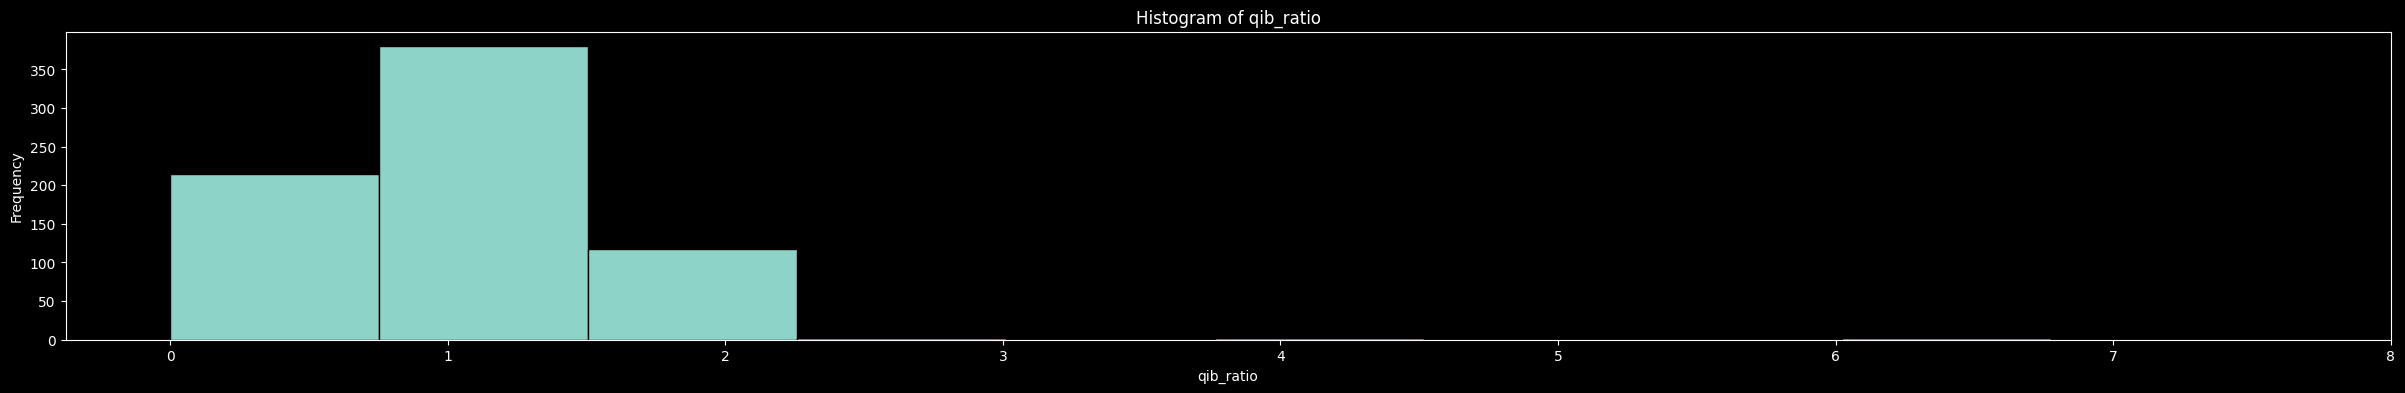

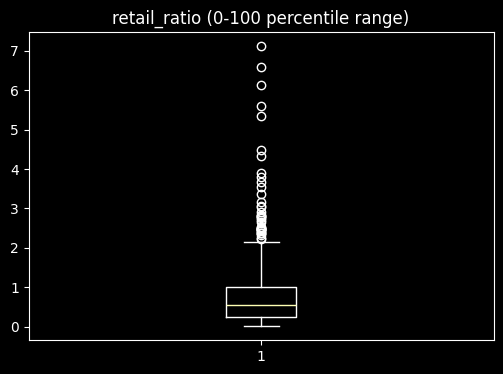

Lower whisker: 0.0141844
25% (Q1): 0.252218
50% (Median): 0.541919
Mean: 0.78757
75% (Q3): 1.01585
Upper whisker: 2.15897


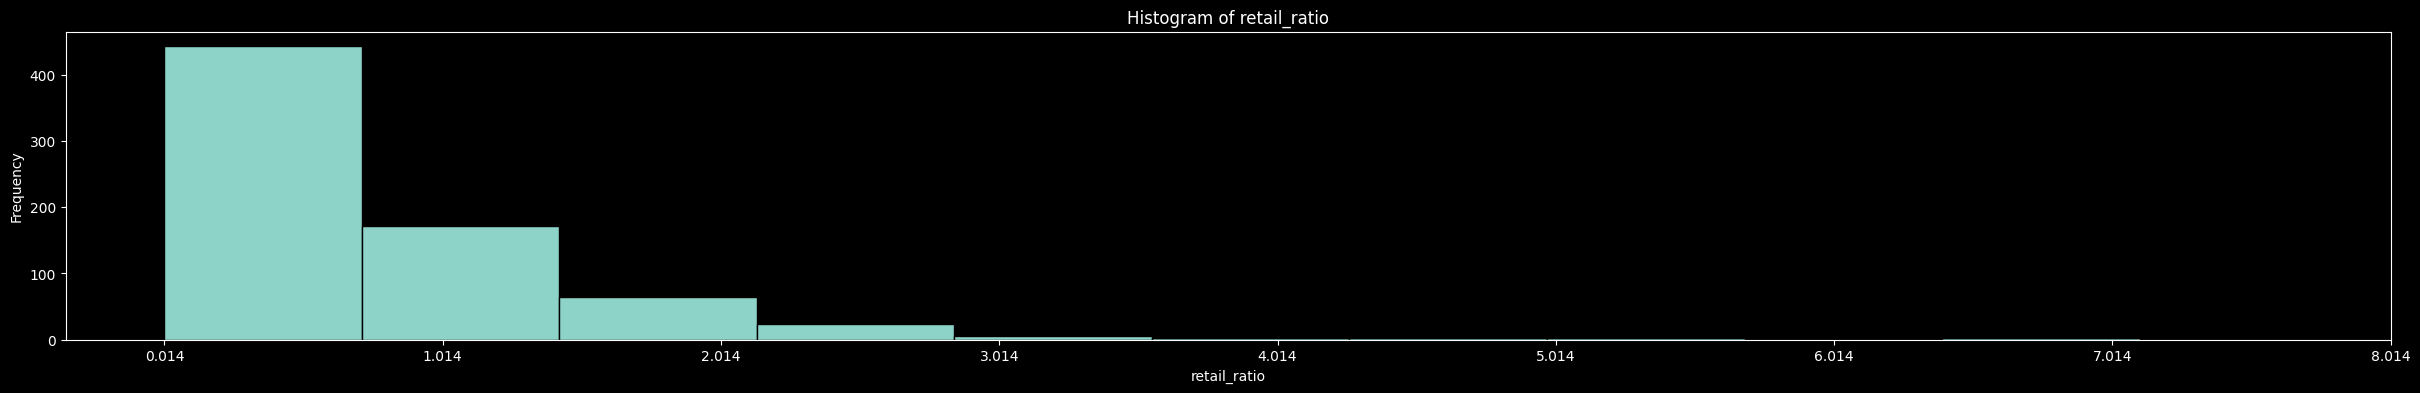

In [7]:
from configs.feature_config import *
features = [
    DERIVED_FEATURES["nii_ratio"],
    DERIVED_FEATURES["qib_ratio"],
    DERIVED_FEATURES["retail_ratio"]
]
for feature in features:
    plot_boxplot_range(df, feature)
    plot_histogram(df, feature, bins=10, step_size=1)

Price Bands

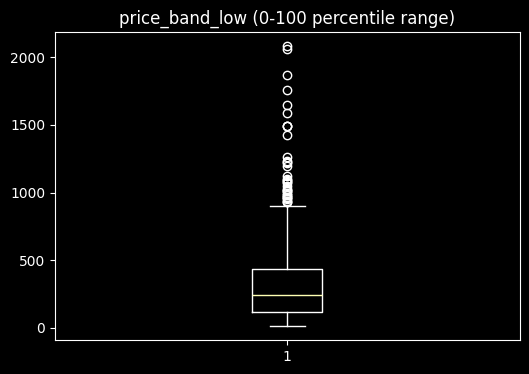

Lower whisker: 12
25% (Q1): 120
50% (Median): 243
Mean: 330.847
75% (Q3): 438.5
Upper whisker: 902


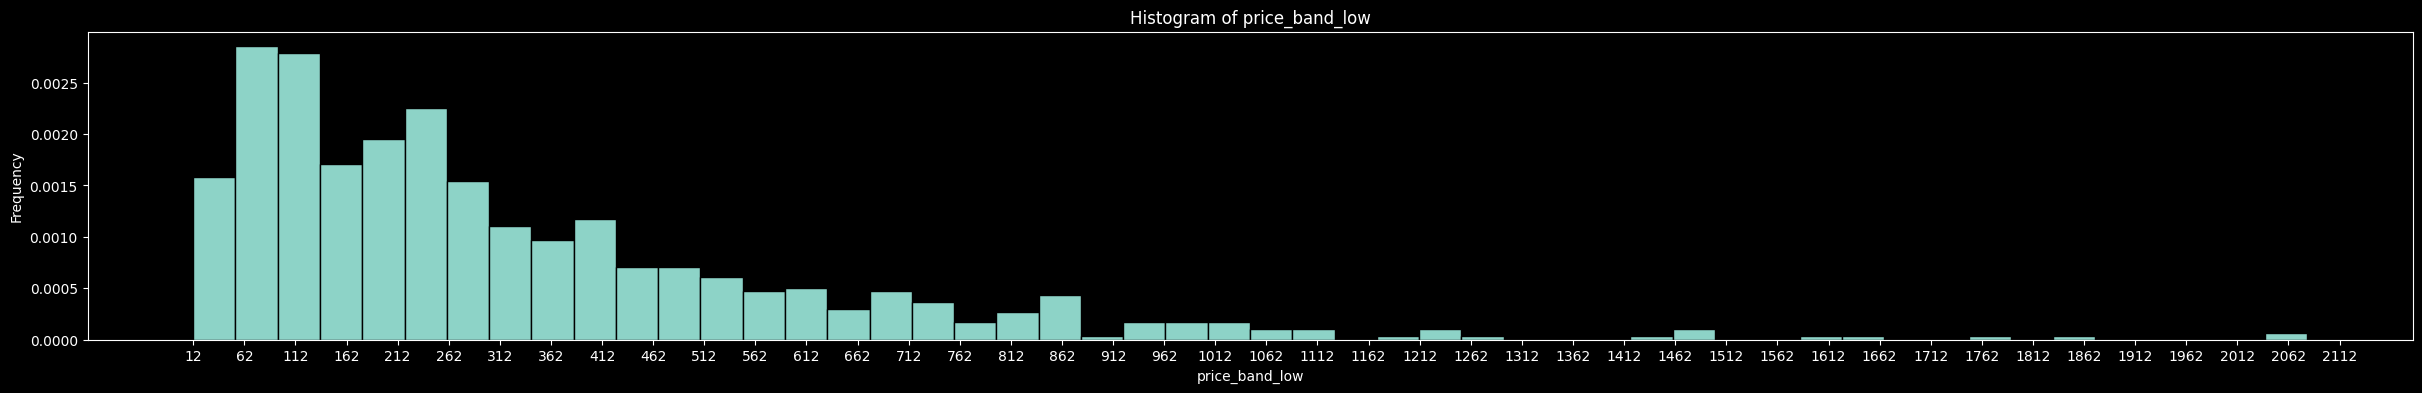

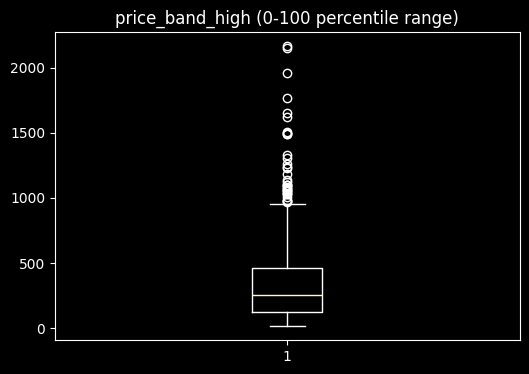

Lower whisker: 14
25% (Q1): 126
50% (Median): 256.5
Mean: 347.729
75% (Q3): 460
Upper whisker: 954


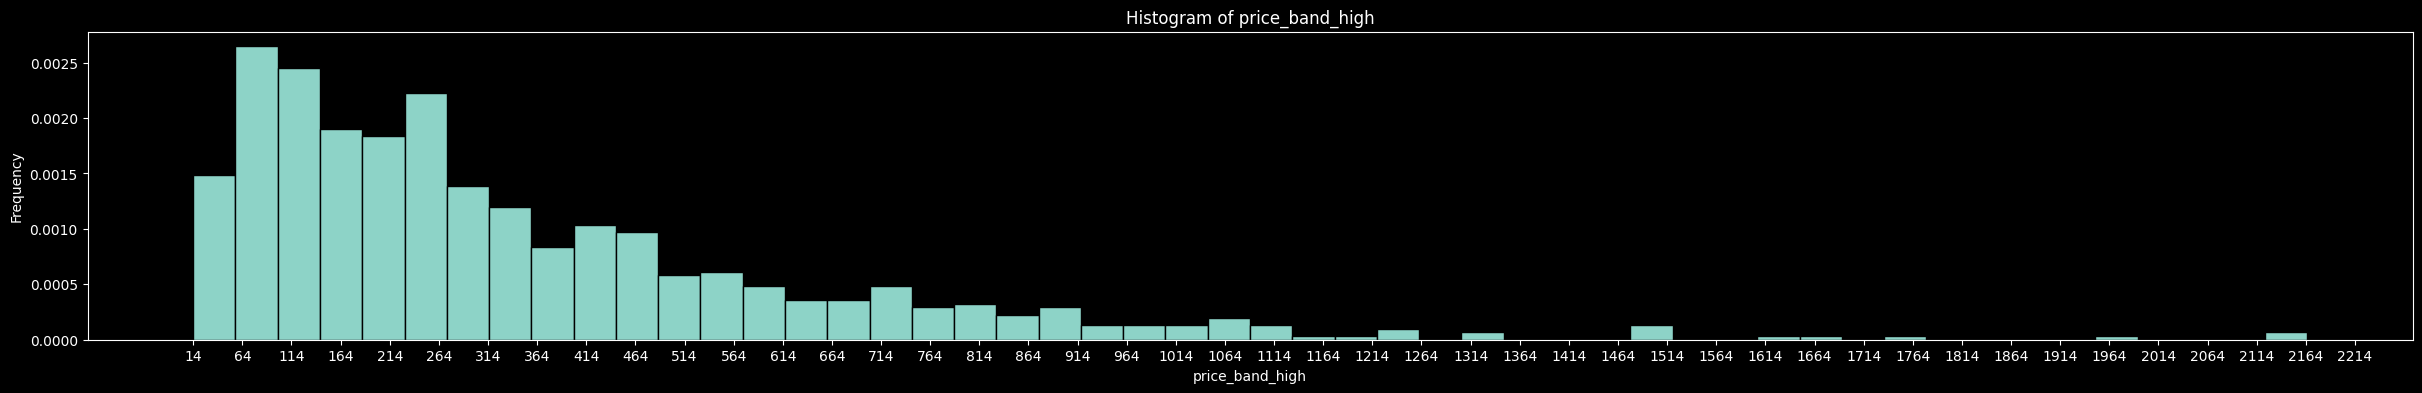

In [8]:
features = [
    RAW_FEATURES["price_band_low"],
    RAW_FEATURES["price_band_high"]
]
for feature in features:
    plot_boxplot_range(df, feature)
    plot_histogram(df, feature, bins=50, step_size=50, density=True)

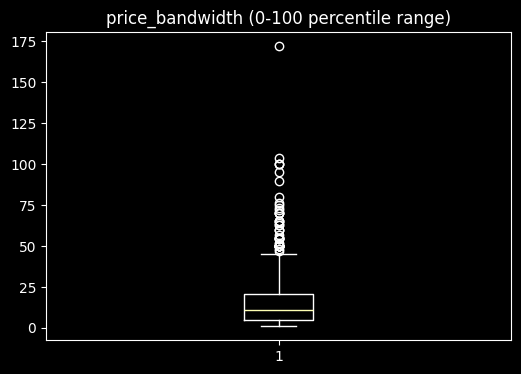

Lower whisker: 1
25% (Q1): 5
50% (Median): 11
Mean: 16.8819
75% (Q3): 21
Upper whisker: 45


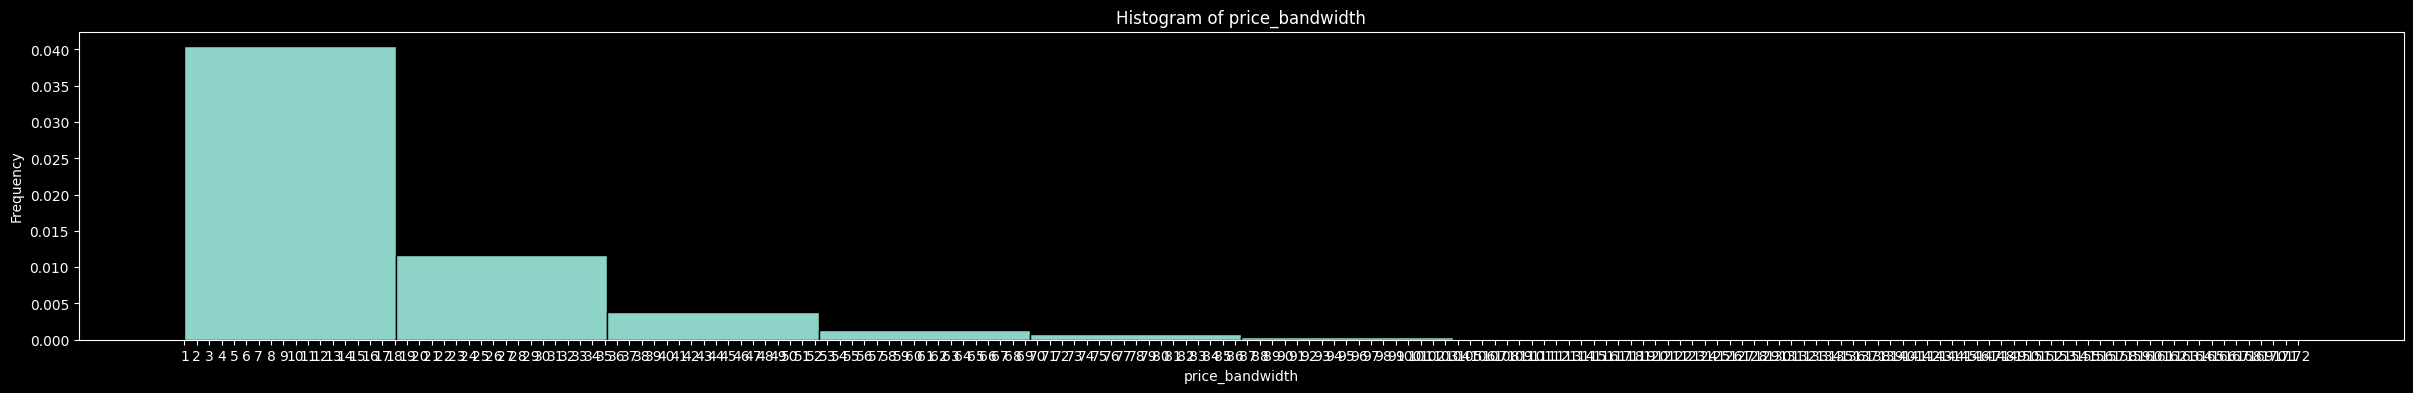

In [9]:
df['price_bandwidth'] = df[RAW_FEATURES['price_band_high']] - df[RAW_FEATURES['price_band_low']]
plot_boxplot_range(df, 'price_bandwidth')
plot_histogram(df, 'price_bandwidth', bins=10, step_size=1, density=True)

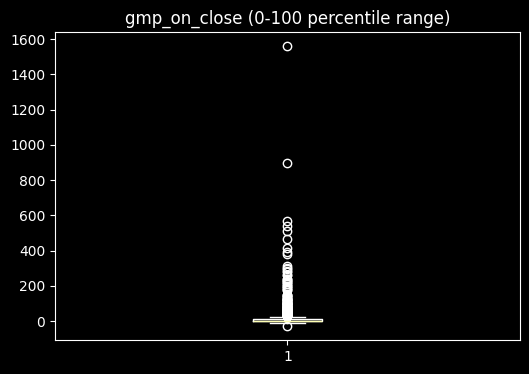

Lower whisker: -10
25% (Q1): 0
50% (Median): 0
Mean: 26.1837
75% (Q3): 10
Upper whisker: 25


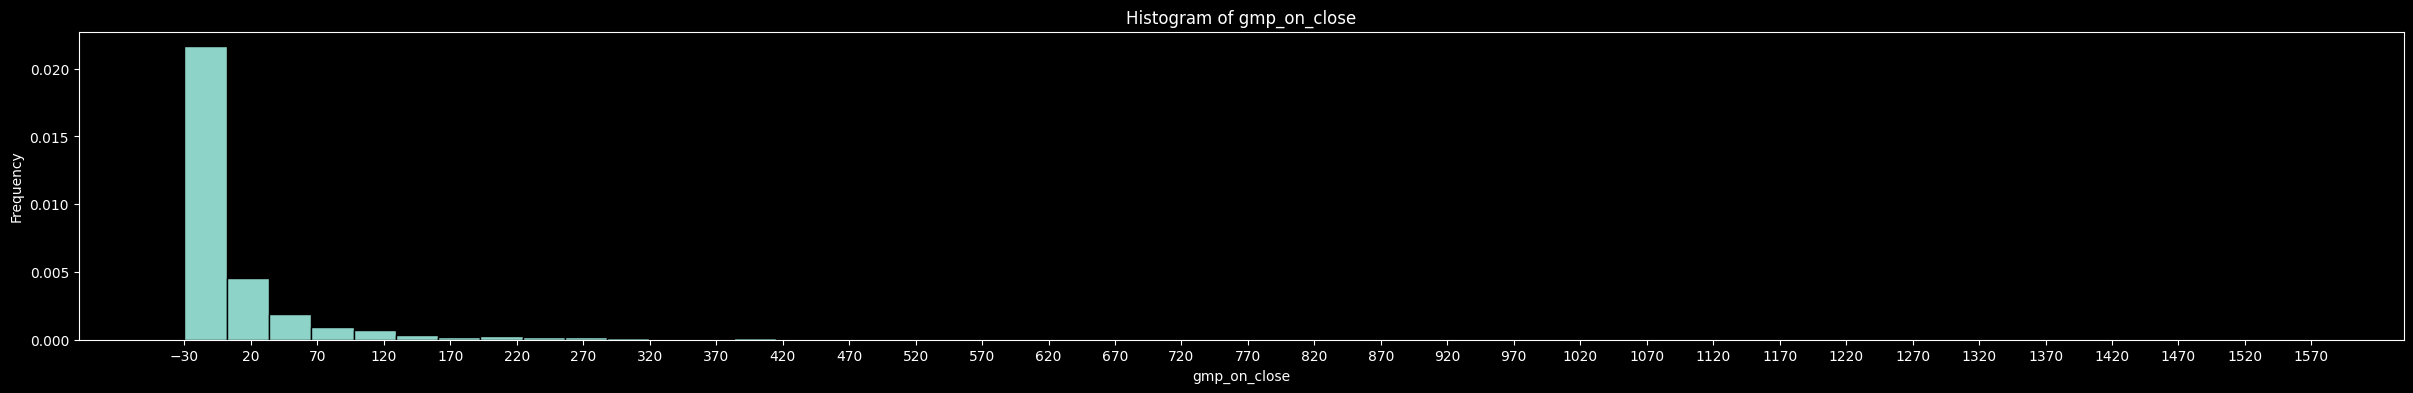

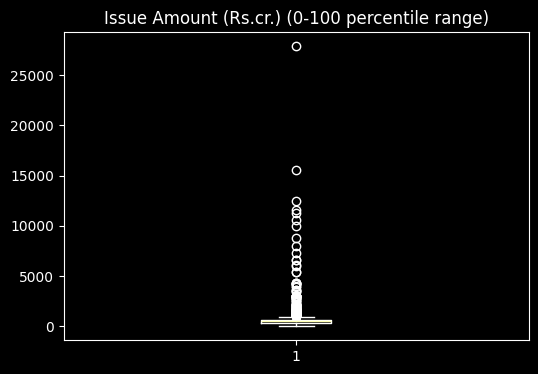

Lower whisker: 14.01
25% (Q1): 350.322
50% (Median): 489.95
Mean: 852.835
75% (Q3): 602.648
Upper whisker: 960.35


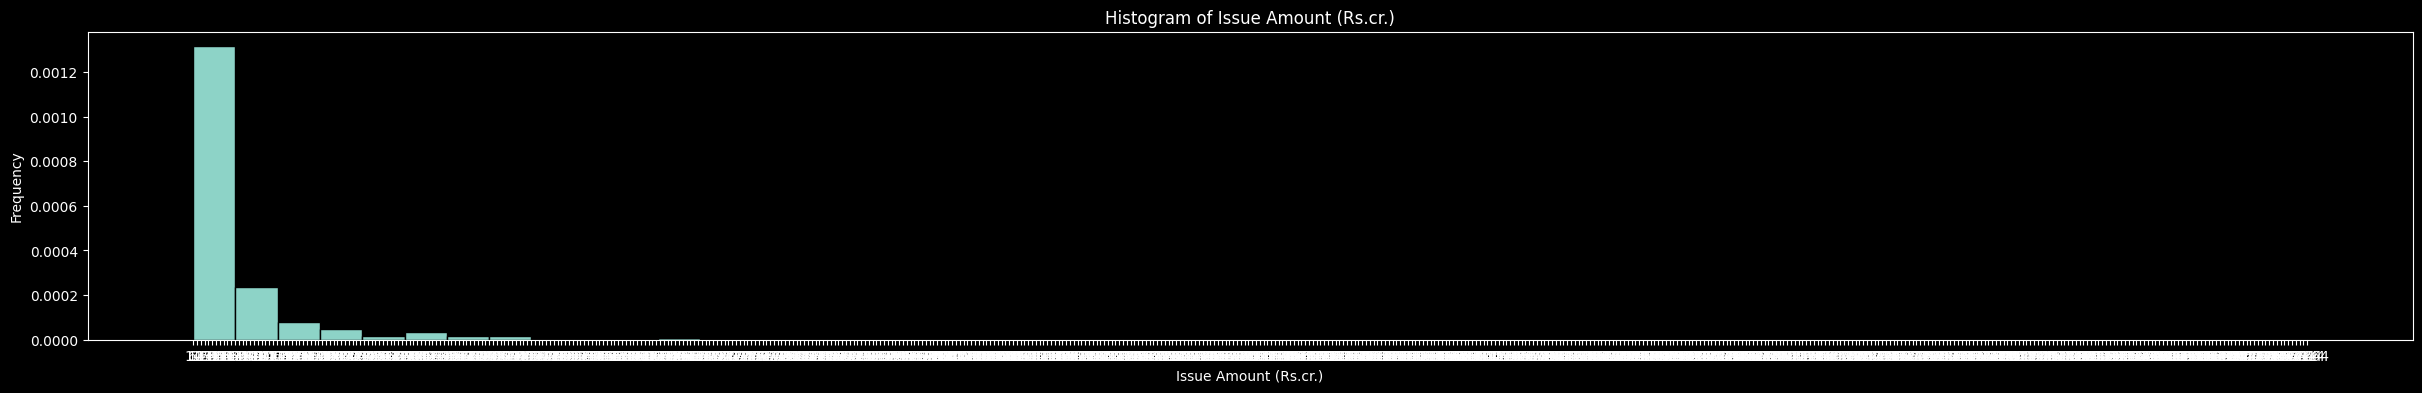

In [10]:
features = [
    RAW_FEATURES["gmp"],
    RAW_FEATURES["issue_amount"]
]
for feature in features:
    plot_boxplot_range(df, feature)
    plot_histogram(df, feature, bins=50, step_size=50, density=True)

In [11]:
from src.features.feature_selection import select_features
select_features(df)

,NII (x),QIB (x),Retail (x),Total (x),qib_ratio,retail_ratio,nii_ratio,year,Issue Amount (Rs.cr.),price_band_high,price_band_low,gmp_on_close
0,4.73,1.180,18.31,3.42,0.345029,5.353801,1.383041,2025,250.80,114.0,108.0,0.0
1,0.45,1.170,0.93,0.98,1.193878,0.948980,0.459184,2025,626.35,384.0,365.0,0.0
2,21.00,50.390,2.42,28.19,1.787513,0.085846,0.744945,2025,10602.65,2165.0,2061.0,0.0
3,15.51,5.580,3.24,6.25,0.892800,0.518400,2.481600,2025,920.00,162.0,154.0,0.0
4,24.73,11.290,2.29,10.12,1.115613,0.226285,2.443676,2025,871.05,460.0,438.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
715,17.62,8.200,12.27,10.57,0.775781,1.160833,1.666982,2006,64.50,150.0,130.0,0.0
716,0.31,9.035,3.44,1.39,6.500000,2.474820,0.223022,2006,40.68,256.5,243.0,0.0
717,22.58,25.240,6.48,17.37,1.453080,0.373057,1.299942,2006,168.49,345.0,295.0,0.0
718,27.97,7.880,38.22,20.23,0.389521,1.889273,1.382600,2006,40.00,21.0,18.0,0.0
